<center><h1>Предобработка данных.</h1></center>

<h2>0. Импорт</h2>

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np

from data_preprocessing import (
    count_duplicated,
    count_pass,
    drop_not_information_columns,
    correct_valute,
    fillna_pass,
    dropnan
)

In [3]:
data = pd.read_csv('/Users/muzaladinovdzamalladinruslanovic/Desktop/PROJECT CIAN/data/full data/cian_all_moscow_full.csv')
print(data.shape)
data.head()

(25979, 18)


,id,url,price,price_per_m2,currency,rooms,area,floor,floors_total,address,metro,metro_minutes,metro_transport,district,description,seller_type,published,room_type_query
0,323665910,https://www.cian.ru/sale/flat/323665910/?mlSea...,4300000,430000,rur,1.0,10.0,3,4,Россия Москва Сиреневый бульвар 15,Щёлковская,15.0,walk,Северное Измайлово,1-комн.кв. · 10 м² · 3/4 этаж,specialist,30 минут назад,1
1,328541004,https://www.cian.ru/sale/flat/328541004/?mlSea...,4699000,319660,rur,1.0,14.7,5,5,"Россия, Москва, улица Артюхиной, 6к2",Текстильщики,12.0,walk,Текстильщики,"1-комн.кв. · 14,7 м² · 5/5 этаж",specialist,вчера,1
2,327589607,https://www.cian.ru/sale/flat/327589607/?mlSea...,4390000,94816,rur,1.0,46.3,3,5,"Россия, Москва, район Вороново, база отдыха Ви...",NaN,NaN,NaN,Клёновское,"1-комн.кв. · 46,3 м² · 3/5 этаж",specialist,два дня назад,1
3,330482104,https://www.cian.ru/sale/flat/330482104/?mlSea...,5000000,142857,rur,1.0,35.0,1,6,"Россия, Москва, проезд Шломина, 6",Смоленская,1.0,walk,Арбат,1-комн.кв. · 35 м² · 1/6 этаж,agency,6 часов назад,1
4,322112389,https://www.cian.ru/sale/flat/322112389/?mlSea...,1999000,48756,rur,1.0,41.0,4,5,"Россия, Москва, 2-я Радиаторская улица, 10",Войковская,4.0,walk,Войковский,Доля · 41 м² · 4/5 этаж,agency,2 недели назад,1


|Столбец          |Что означает                                            |Пример                            |
|-----------------|--------------------------------------------------------|----------------------------------|
|`id`             |Уникальный ID объявления на Циане                       |`327785311`                       |
|`url`            |Ссылка на объявление                                    |`https://cian.ru/sale/flat/...`   |
|`price`          |Цена в рублях                                           |`21410340`                        |
|`price_per_m2`   |Цена за 1 м² в рублях                                   |`804900`                          |
|`currency`       |Валюта (`rur`, `eur`, `usd`)                            |`rur`                             |
|`rooms`          |Количество комнат (`Nan` - студия)                      |`1`, `2`, `3`…                    |
|`area`           |Общая площадь в м²                                      |`26.6`                            |
|`floor`          |Этаж квартиры                                           |`7`                               |
|`floors_total`   |Всего этажей в доме                                     |`37`                              |
|`address`        |Адрес как на Циане                                      |`Москва, ЖК Эра, 6`               |
|`metro`          |Ближайшая станция метро                                 |`Павелецкая`                      |
|`metro_minutes`  |Минут до метро                                          |`8`                               |
|`metro_transport`|Способ до метро: `walk` или `transport`                 |`walk`                            |
|`district`       |Район Москвы                                            |`Замоскворечье`                   |
|`description`    |Краткое описание (авто)                                 |`1-комн.кв. · 26,6 м² · 7/37 этаж`|
|`seller_type`    |Кто продаёт                                             |`owner`                           |
|`published`      |Когда опубликовано                                      |`вчера`, `2 дня назад`            |
|`room_type_query`|Код типа комнат в запросе (1-6, 9=студия)               |`1`                               |

<h5>0.1 Проверка на дубликаты.</h5>

In [4]:
count_duplicated(data)

Количество дубликатов - 0


<h5>0.2 Количество пропусков.</h5>

Количество пропусков по столбцам:
 id                    0
url                   0
price                 0
price_per_m2          0
currency              0
rooms              2967
area                  0
floor                 0
floors_total          0
address               0
metro               114
metro_minutes       119
metro_transport     119
district              0
description           0
seller_type        1259
published             0
room_type_query       0
dtype: int64


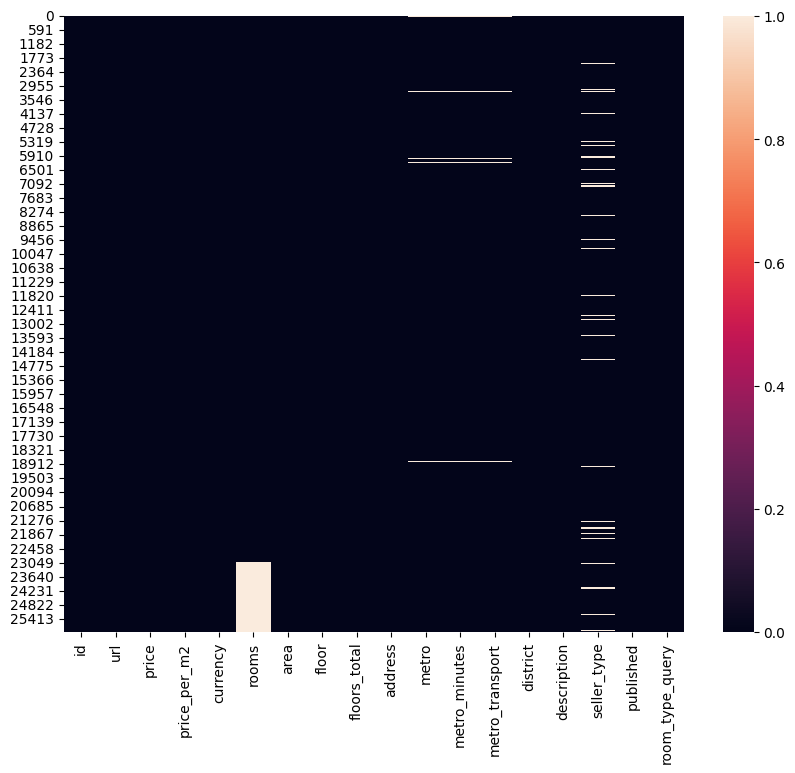

In [5]:
count_pass(data)

* rooms - пропуски в данном случае отражают квартиры студии
* metro, metrominutes, metro_transport - в большинстве случаев, эти пропуски обусловлены тем, что недвижимость находится за МКАДом, данные будут удалены, так как исследую цены на квартиры
* seller_type - изучив признак, будет приниматься решение для него, если цена квартиры будет иметь значение взависимости от типы продажи, то пропуски будут заполняться

<h2>1.1 Удаление неинформативных признаков - id, url, price_per_m2, description, published, room_type_query</h2>

In [6]:
data = drop_not_information_columns(data, 'id', 'url', 'price_per_m2', 'description', 'published', 'room_type_query', 'address')

* id - каждый индивидуален - неинформативен 
* url - каждая индивидуальна - неинформативен
* price_per_m2 - утечка данных из признака price - утечка целевой переменной
* description - данный признак уже преобразован и находится в столбцах - rooms, area, floors_total - нет необходимости
* published - время публикации с момента парсинга - неинформативен
* room_type_query - данный признак уже содержится в rooms - нет необходимости

<h2>1.2 Изменение признака - currency</h2>

In [7]:
data = correct_valute(data)

<h2>1.3 Заполнение/Удаление пропусков.</h2>

* rooms - заполниv 0-ми - квартира студия
* metro/metro_minutes/metro_transport - пропуски удаляем
* seller_type - пропуски заполним значением owner

In [8]:
data = dropnan(data, 'metro', 'metro_minutes', 'metro_transport')
data = fillna_pass(data, rooms=0, seller_type='owner')

<h4>Сохранение и перемешивание</h4>

In [9]:
data = data.sample(frac=1, random_state=42).reset_index(drop=True)
data.to_csv('/Users/muzaladinovdzamalladinruslanovic/Desktop/PROJECT CIAN/data/full data/cian_preprocessing.csv')